In [101]:
import glob
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import numpy as np
from regions import Regions
from astropy.nddata import Cutout2D
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.table import Table, vstack

def get_sat_catalogs(filter='F140M'):
    cat_files = glob.glob(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/{filter}/pipeline/*destreak*satstar_catalog.fits')
    """
    wav = filter[1:-1]
    if int(wav)<300:
        pixel_scale = 0.031 * u.arcsec
    else:
        pixel_scale = 0.063 * u.arcsec
    """
    fwhm_tbl = Table.read('/orange/adamginsburg/jwst/w51/reduction/fwhm_table.ecsv')
    row = fwhm_tbl[fwhm_tbl['Filter'] == filter.upper()]
    fwhm = u.Quantity(float(row['PSF FWHM (arcsec)'][0]), u.arcsec)
    print(f"Using FWHM={fwhm:.3f}")
    
    for i, f in enumerate(cat_files):
        sat_hdul = fits.open(f)
        

        # column names: use the FITS API that exists on BinTableHDU
        try:
            colnames = sat_hdul[1].columns.names
        except Exception:
            # fallback to numpy dtype names if columns isn't available
            try:
                colnames = list(sat_hdul[1].data.dtype.names)
            except Exception:
                colnames = None
        tab = sat_hdul[1].data
        xpos = tab['x_fit']
        ypos = tab['y_fit']
        ra = tab['skycoord_fit.ra']
        dec = tab['skycoord_fit.dec']

        
        skycoords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
        idx, d2d, d3d = skycoords.match_to_catalog_sky(skycoords)  
        # check for duplicates within fwhm
        # ignore self-matches by excluding zero distances

        duplicate = ((d2d < fwhm) & (d2d>0*u.arcsec))
        if np.any(duplicate):
            print(f"Warning: {np.sum(duplicate)} duplicate sources found in {f}, removing them")
            tab = tab[~duplicate]
            xpos = xpos[~duplicate]
            ypos = ypos[~duplicate]
            ra = ra[~duplicate]
            dec = dec[~duplicate]
            skycoords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
        if i ==0:
            basecoords = skycoords
            base_tab = Table(tab)
        else:
            idx, d2d, d3d = skycoords.match_to_catalog_sky(basecoords)

            same = d2d < fwhm

            # update base table if qfit is higher -- assuming that lower qfit is more reliable
            #base_tab_qfit_to_be_updated = base_tab['qfit'][idx][same]
            #print(base_tab['qfit'][idx][same])
            #tab_qfit_to_be_updated = tab['qfit'][same]
            #update_idx = np.where(base_tab_qfit_to_be_updated - tab_qfit_to_be_updated > 0)[0]
            #base_tab[idx][same][update_idx] = tab[same][update_idx]
            # add new sources that are not matched
            not_same = d2d >= fwhm
            base_tab = vstack([base_tab, Table(tab[not_same])])


        """
        img = fits.getdata(f.replace('_satstar_catalog.fits', '.fits'))
        wcs = WCS(fits.getheader(f.replace('_satstar_catalog.fits', '.fits')))
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection=wcs)
        norm = simple_norm(img, 'sqrt', percent=99.5)
        ax.imshow(img, norm=norm, origin='lower', cmap='gray', interpolation='nearest')
        ax.set_xlabel('RA')
        ax.set_ylabel('Dec')
        ax.set_title(f.split('/')[-1])
        ax.scatter(xpos, ypos, s=100, edgecolor='red', facecolor='none', marker='o', label='Saturated Stars')
        ax.legend(loc='upper right')
        plt.show()
        plt.close()
        """
    print(f"Final catalog has {len(base_tab)} sources")
    return base_tab

In [ ]:
ㅇㄹㅇㄹㅇㄹㅇㄹㅇㄹㅇㄹㅇㄹㄹㄹㄹㅇㄹㅇㄹㅇㄹㅇㅇㄹㅇㄹㅇㄹㅇㄹㄹㅇㄹㅇㄹㅇㄹㅇㄹㅇㄹㅇㄹㅇㄹ

Using FWHM=0.048 arcsec
Final catalog has 4827 sources
Final catalog has 4827 sources


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


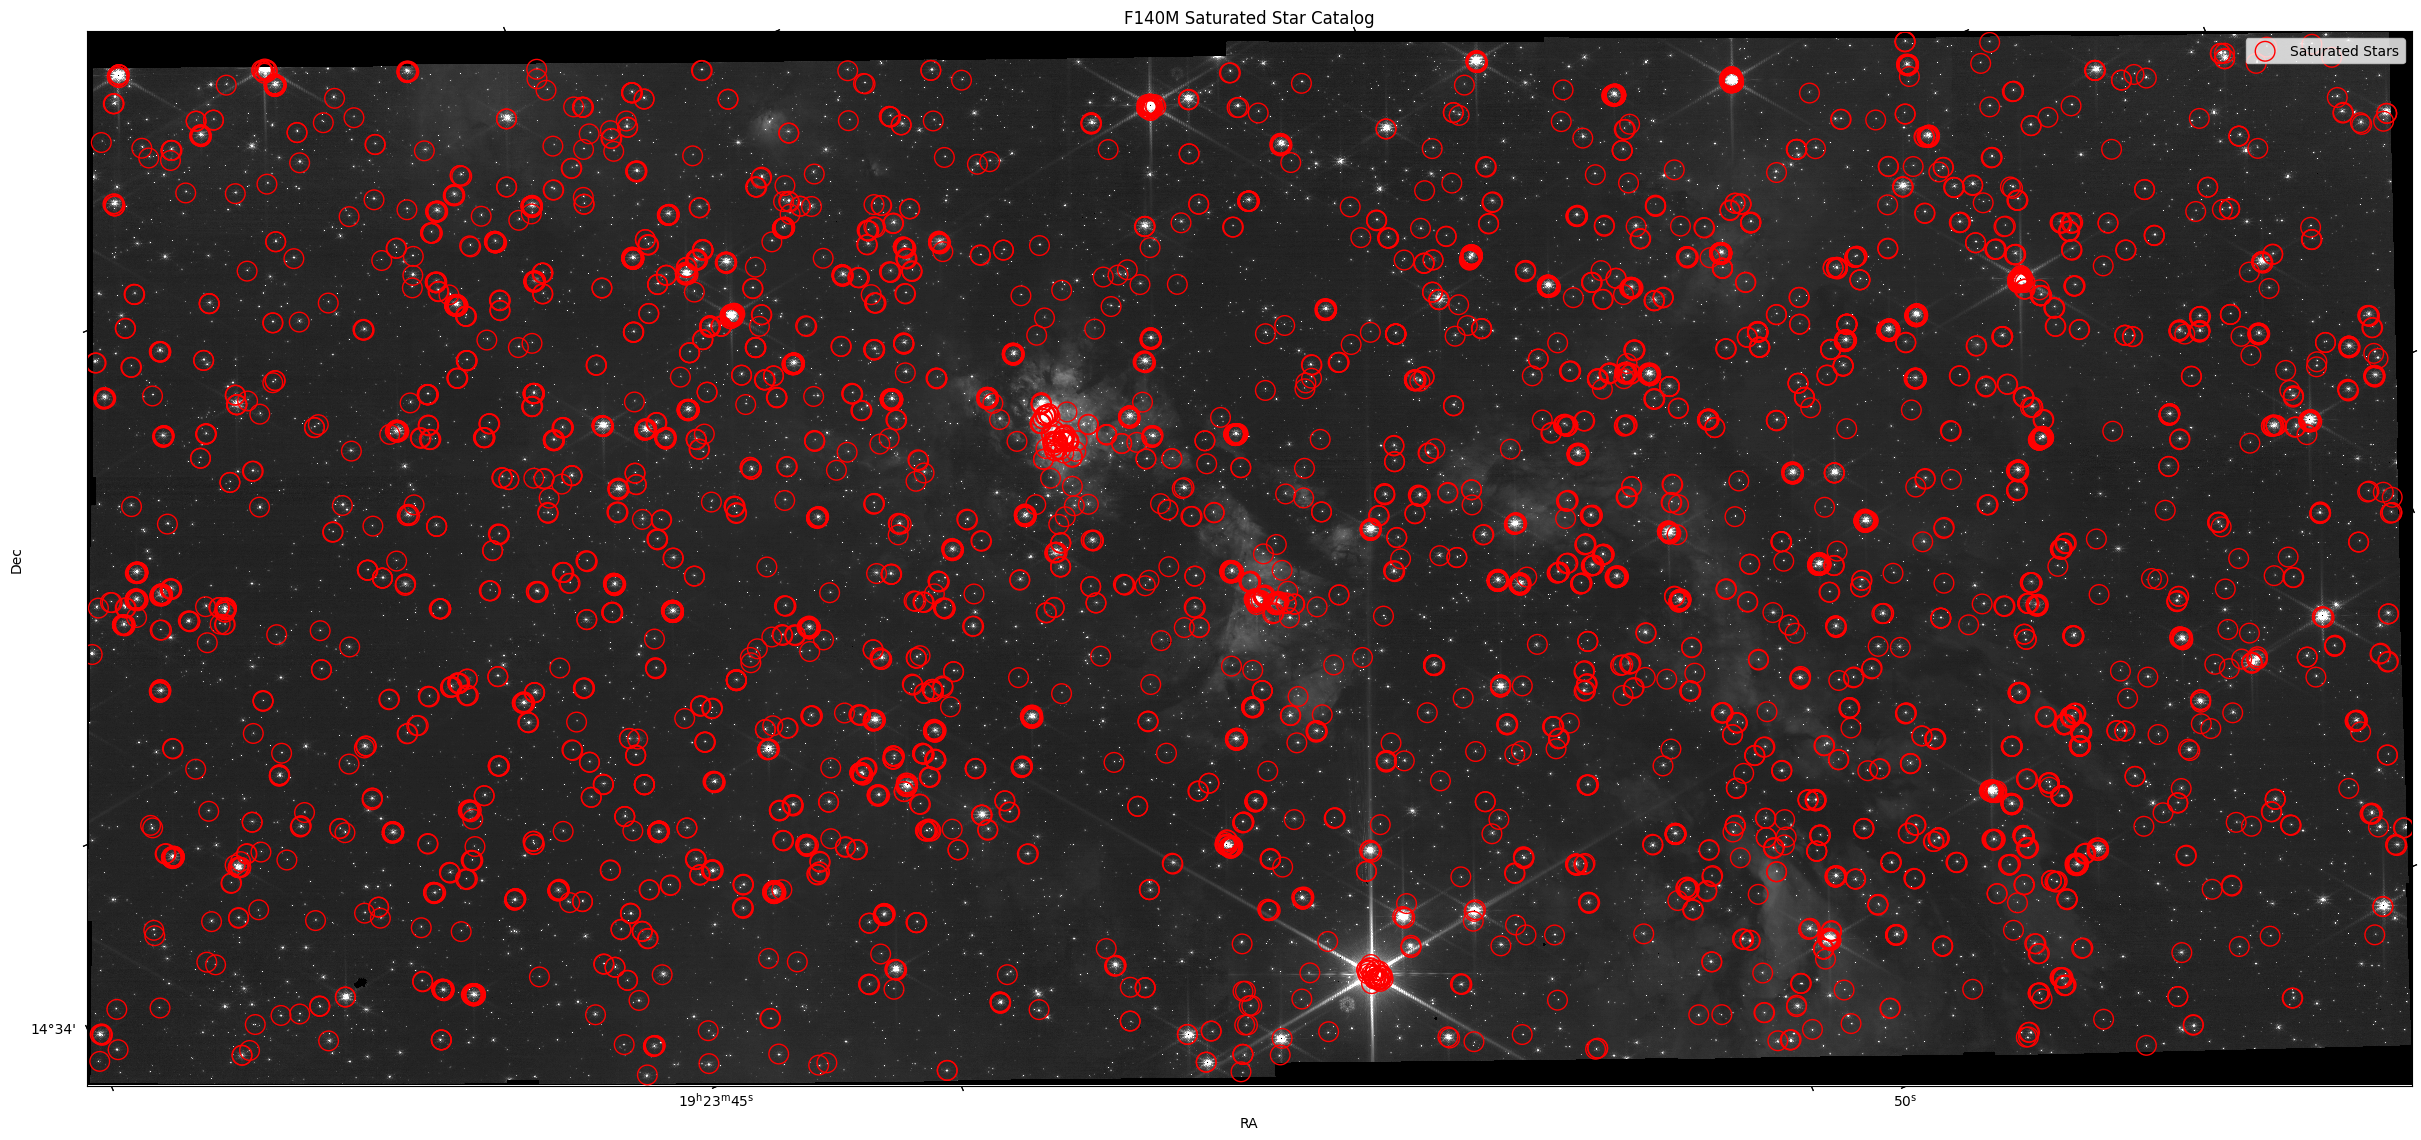

ho 4827


In [102]:
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_cat = get_sat_catalogs('F140M')
# keep only the sources that has saturated pixel within FWHM
img_f140m = fits.getdata(image_filenames['f140m'])
wcs_f140m = WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1)))   

skycoord_f140_sat = SkyCoord(ra=f140m_cat['skycoord_fit.ra']*u.deg, dec=f140m_cat['skycoord_fit.dec']*u.deg, frame='icrs')
pixel_coords_f140_sat = wcs_f140m.world_to_pixel(skycoord_f140_sat)
fig = plt.figure(figsize=(30, 30))
ax = fig.add_subplot(111, projection=wcs_f140m)
norm = simple_norm(img_f140m, 'sqrt', percent=99.5)
ax.imshow(img_f140m, norm=norm, origin='lower', cmap='gray', interpolation='nearest')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_title('F140M Saturated Star Catalog')
ax.scatter(pixel_coords_f140_sat[0], pixel_coords_f140_sat[1], s=200, edgecolor='red', facecolor='none', marker='o', label='Saturated Stars')
ax.legend(loc='upper right')
plt.show()

tab = Table()
tab['ra'] = f140m_cat['skycoord_fit.ra']
tab['dec'] = f140m_cat['skycoord_fit.dec']
tab['flux'] = f140m_cat['flux_fit']
print('ho',len(tab['ra']))
tab.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f140m_merged_saturated_stars_candidates.fits', overwrite=True)


In [103]:
ddd

NameError: name 'ddd' is not defined

In [ ]:
tab_original = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_nircam_indivexp_merged_dao_refined.fits')
skycoord_f140_original = tab_original['skycoord']
pixcoords_f140_original = skycoord_f140_original.to_pixel(WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1))))

# collect pixel within FWHM of each source
mask = np.zeros(img_f140m.shape, dtype=bool)
keep_idx = []
for i, sc in enumerate(skycoord_f140_sat):
    idx, d2d, d3d = sc.match_to_catalog_sky(skycoord_f140_original)
    within_fwhm = d2d < 0.031*6*u.arcsec   # 10 pixels
    cutout = Cutout2D(img_f140m, position=sc, size=0.031*8*u.arcsec, wcs=wcs_f140m, mode='partial', fill_value=0)
    cutout_mask = np.isnan(cutout.data) | (cutout.data <= 0) | ~within_fwhm  # assuming the saturation limit is 65000
    if np.any(cutout_mask):
        keep_idx.append(i)
print(len(keep_idx), "sources have saturated pixels within FWHM")
f140m_cat = f140m_cat[keep_idx]
# keep only sources that has saturated pixels within FWHM

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


1178 sources have saturated pixels within FWHM


1178


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Number of saturated stars in F140M: 1178
Number of original catalog stars in F140M: 23533
[3125.10965497 3503.70159121 3541.08220844 ... 5748.08183792 6114.46516455
 7830.2971371 ]


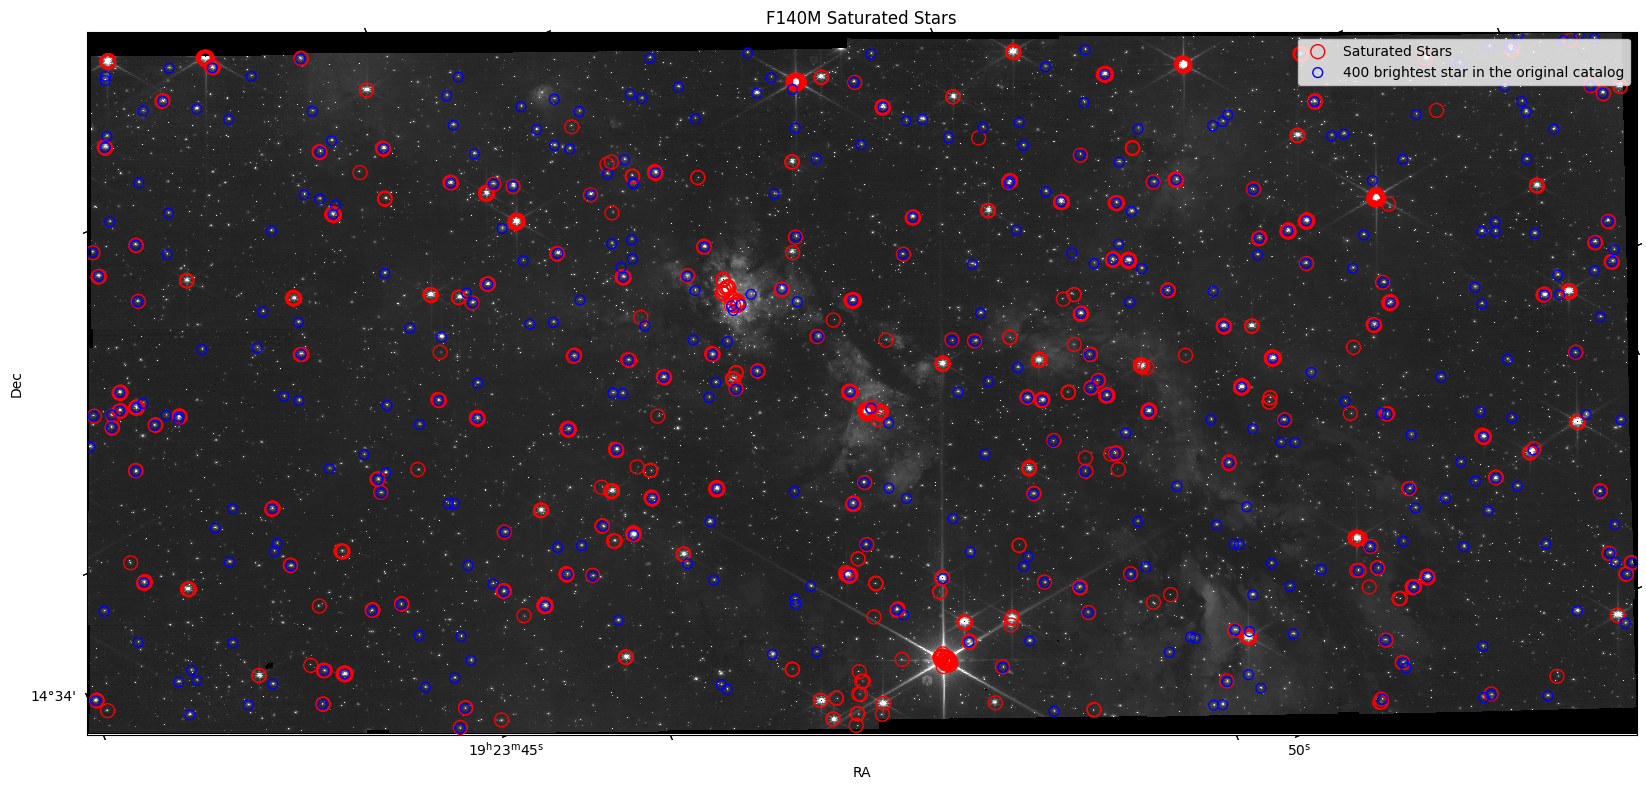

In [ ]:


flux_f140_original = tab_original['flux_fit_f140m']
flux_f140_original_unmasked = flux_f140_original.copy()[~flux_f140_original.mask]
flux_sort_idx = np.argsort(flux_f140_original_unmasked)[::-1]
skycoord_f140_original_unmasked = skycoord_f140_original[~flux_f140_original.mask]
pixcoords_f140_original_unmasked = skycoord_f140_original_unmasked.to_pixel(WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1))))

skycoords_f140_sat = SkyCoord(ra=f140m_cat['skycoord_fit.ra']*u.deg, dec=f140m_cat['skycoord_fit.dec']*u.deg, frame='icrs')
print(len(skycoords_f140_sat))
pixcoords_f140_sat = skycoords_f140_sat.to_pixel(WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1))))
img_f140m = fits.getdata(image_filenames['f140m'])
wcs_f140m = WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1)))   
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection=wcs_f140m)
norm = simple_norm(img_f140m, 'sqrt', percent=99.5)
ax.imshow(img_f140m, norm=norm, origin='lower', cmap='gray', interpolation='nearest')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_title('F140M Saturated Stars')
ax.scatter(pixcoords_f140_sat[0], pixcoords_f140_sat[1], s=100, edgecolor='red', facecolor='none', marker='o', label='Saturated Stars')
print(f"Number of saturated stars in F140M: {len(pixcoords_f140_sat[0])}")
print(f"Number of original catalog stars in F140M: {len(pixcoords_f140_original[0])}")
print(pixcoords_f140_original[0])


ax.scatter(pixcoords_f140_original_unmasked[0][flux_sort_idx[:400]], pixcoords_f140_original_unmasked[1][flux_sort_idx[:400]], s=50, edgecolor='blue', facecolor='none', marker='o', label='400 brightest star in the original catalog')
ax.legend(loc='upper right')

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


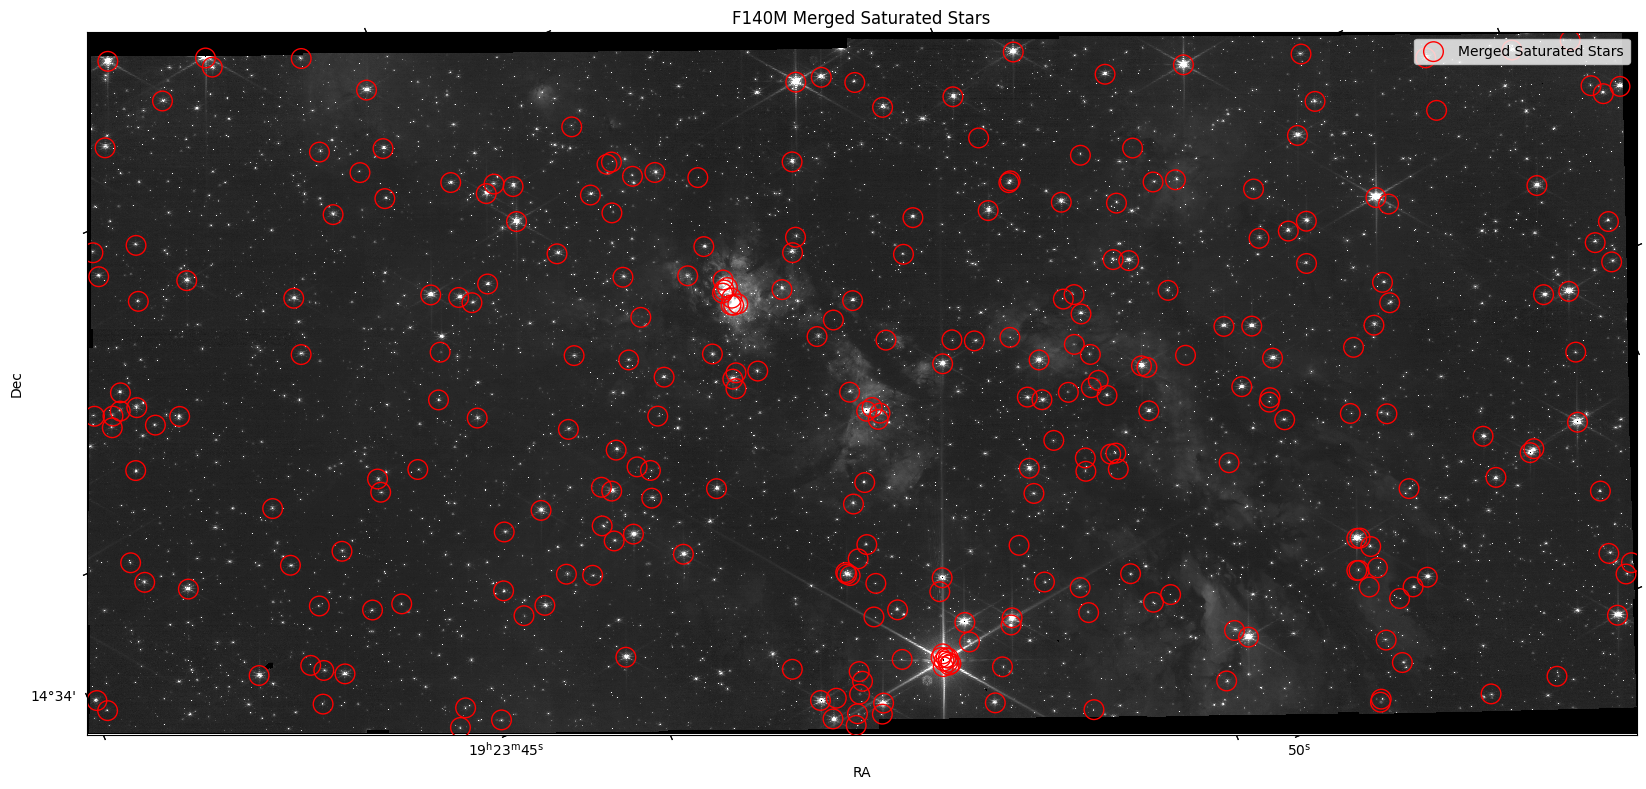

In [ ]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


def merge_close_sources(ra, dec, max_sep=1.0*u.arcsec, return_groups=False):
    """
    Group and merge sources that are within a given angular separation.

    Parameters
    ----------
    ra, dec : array-like
        Right Ascension and Declination in degrees.
    max_sep : Quantity
        Maximum angular separation for grouping (e.g., 1*u.arcsec).
    return_groups : bool, optional
        If True, also return a list of arrays giving indices of original
        sources in each merged group.

    Returns
    -------
    merged_coords : SkyCoord
        Sky coordinates of merged (averaged) positions.
    labels : ndarray
        Integer array giving group label for each original source.
    groups : list of arrays, optional
        Only returned if return_groups=True.
        Each element contains indices of sources belonging to that group.
    """
    ra = np.asarray(ra)
    dec = np.asarray(dec)
    coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

    # find all pairs within max_sep
    idx1, idx2, sep2d, _ = coords.search_around_sky(coords, max_sep)

    n = len(coords)
    adj = csr_matrix((np.ones_like(idx1), (idx1, idx2)), shape=(n, n))

    n_groups, labels = connected_components(adj, directed=False)

    # average RA/Dec within each group
    group_ra = np.zeros(n_groups)
    group_dec = np.zeros(n_groups)
    groups = []

    for i in range(n_groups):
        members = np.where(labels == i)[0]
        groups.append(members)
        group_ra[i] = np.mean(ra[members])
        group_dec[i] = np.mean(dec[members])

    merged_coords = SkyCoord(ra=group_ra*u.deg, dec=group_dec*u.deg)

    if return_groups:
        return merged_coords, labels, groups
    else:
        return merged_coords, labels

merged_coords, labels, groups = merge_close_sources(skycoords_f140_sat.ra, skycoords_f140_sat.dec, 15*0.031*u.arcsec, return_groups=True)


fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection=wcs_f140m)
norm = simple_norm(img_f140m, 'sqrt', percent=99.5)
ax.imshow(img_f140m, norm=norm, origin='lower', cmap='gray', interpolation='nearest')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_title('F140M Merged Saturated Stars')
merged_pixcoords = merged_coords.to_pixel(WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1))))
ax.scatter(merged_pixcoords[0], merged_pixcoords[1], s=200, edgecolor='red', facecolor='none', marker='o', label='Merged Saturated Stars')
ax.legend(loc='upper right')
plt.show()
tab = Table()
tab['skycoord'] = merged_coords
tab.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f140m_merged_saturated_stars_candidates.fits', overwrite=True)
